<a href="https://colab.research.google.com/github/capedcrusader03-ops/Netflix-Content-Analysis/blob/main/Netflix_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import opendatasets as od

sns.set_theme(style='whitegrid')


In [ ]:
od.download("https://www.kaggle.com/datasets/shivamb/netflix-shows?utm_source=chatgpt.com")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: capedcrusader404
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows


100%|██████████| 1.34M/1.34M [00:01<00:00, 1.37MB/s]


In [ ]:
df= pd.read_csv("/content/netflix-shows/netflix_titles.csv")

In [ ]:

print(df.shape)

print(df.dtypes)

print(df.isnull().sum())

print(df.duplicated().sum())

print(df.describe(include='all'))


(8807, 12)
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64
0
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  Movie  Zubaan  Rajiv Chilaka  David Attenborough   
freq         1   6131       1             19                  19   
mean       NaN    NaN     NaN            NaN                 NaN   
std        NaN    NaN   

In [ ]:
df.drop_duplicates(inplace=True)

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

df.columns = df.columns.str.lower()

print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                            Unknown  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...        Unknown   
3                                            Unknown        Unknown   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

  date_added  release_year rating   duration  \
0 2021-09-25          2020  PG-13     90 min   
1 2021-09-24          2021  TV-MA  2 Seasons   
2 2021-09-24          2021  TV-MA   1 Season   
3 2021-0

In [ ]:
# Year Added

df['year_added'] = df['date_added'].dt.year

# Month Added

df['month_added'] = df['date_added'].dt.month_name()

# Content Age

current_year = 2026

df['content_age'] = current_year - df['release_year']

# Extract numeric duration

df['duration_num'] = df['duration'].str.extract(r'(\d+)')
df['duration_num'] = pd.to_numeric(df['duration_num'])

# Duration Category

def duration_category(x):
    if x < 60:
        return 'Short'
    elif x < 120:
        return 'Medium'
    else:
        return 'Long'


df['duration_category'] = df['duration_num'].apply(duration_category)

# Decade Category

def decade(year):
    if year < 2000:
        return '1990s'
    elif year < 2010:
        return '2000s'
    elif year < 2020:
        return '2010s'
    else:
        return '2020s'


df['decade'] = df['release_year'].apply(decade)

print(df[['year_added','month_added','content_age','duration_category','decade']].head())

   year_added month_added  content_age duration_category decade
0      2021.0   September            6            Medium  2020s
1      2021.0   September            5             Short  2020s
2      2021.0   September            5             Short  2020s
3      2021.0   September            5             Short  2020s
4      2021.0   September            5             Short  2020s


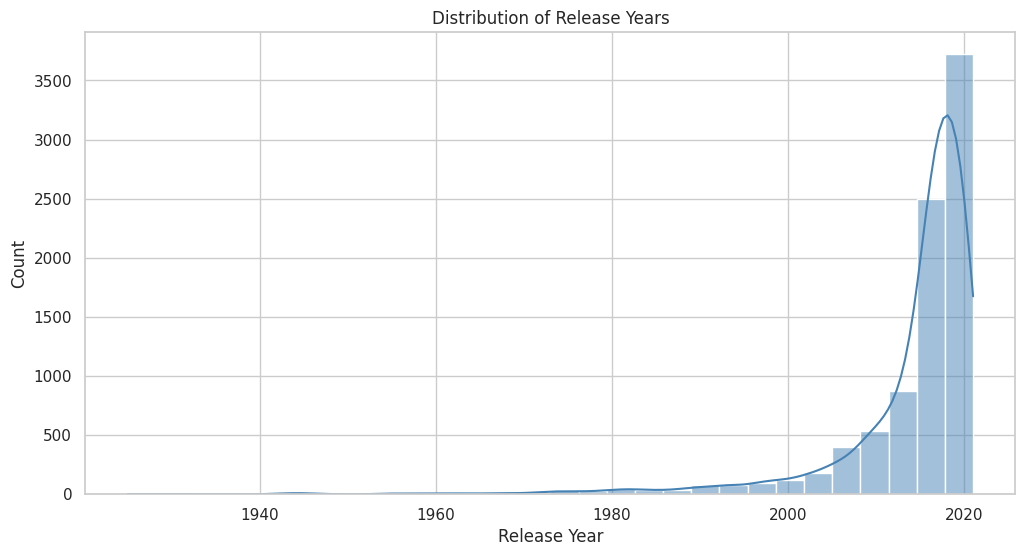

In [ ]:
plt.figure(figsize=(12,6))

sns.histplot(df['release_year'], bins=30, kde=True, color='steelblue')

plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')

plt.show()


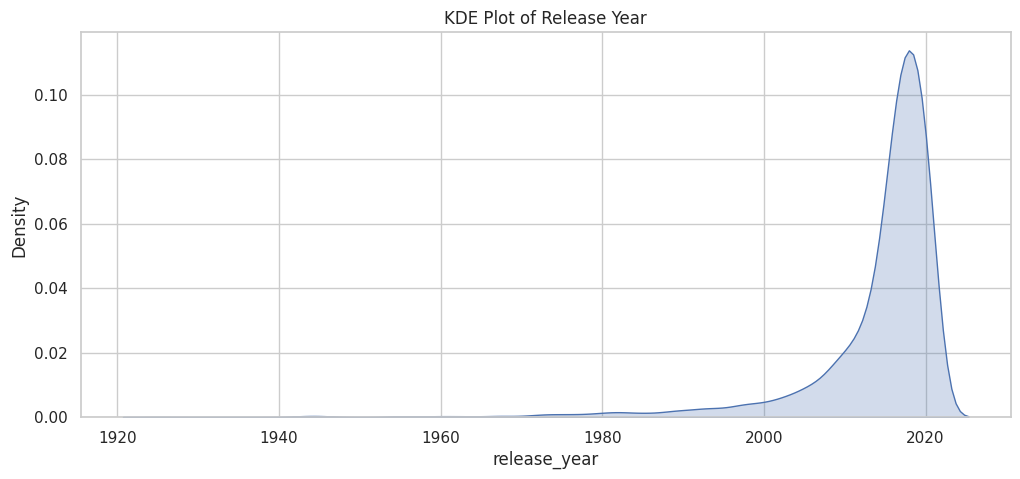

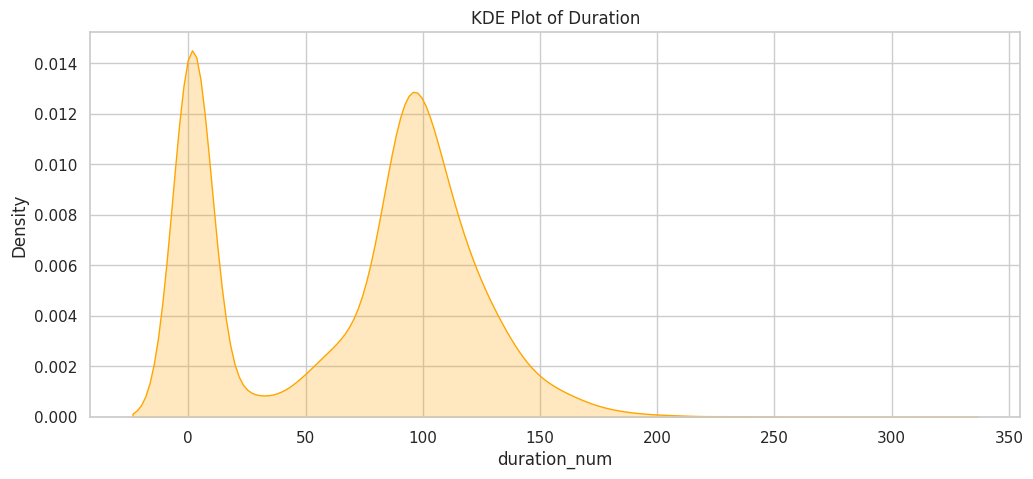

In [ ]:
plt.figure(figsize=(12,5))

sns.kdeplot(df['release_year'], fill=True)

plt.title('KDE Plot of Release Year')
plt.show()
plt.figure(figsize=(12,5))

sns.kdeplot(df['duration_num'], fill=True, color='orange')

plt.title('KDE Plot of Duration')
plt.show()


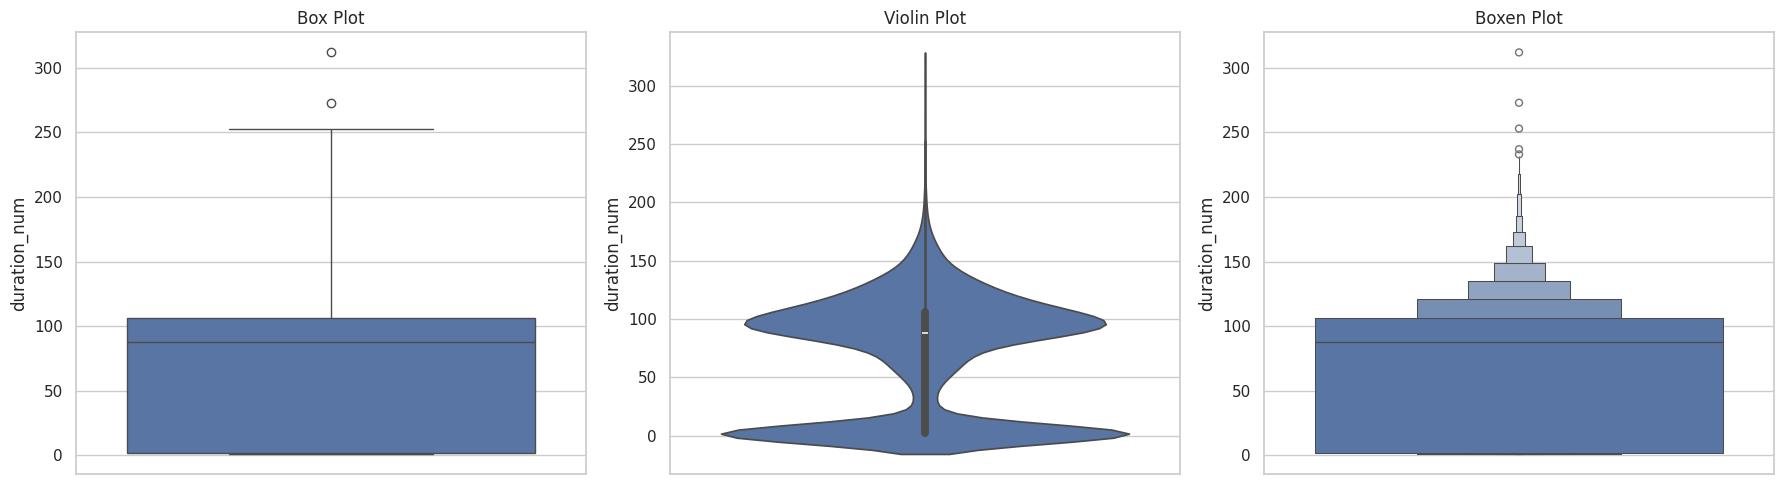

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

sns.boxplot(y=df['duration_num'], ax=axes[0])
axes[0].set_title('Box Plot')

sns.violinplot(y=df['duration_num'], ax=axes[1])
axes[1].set_title('Violin Plot')

sns.boxenplot(y=df['duration_num'], ax=axes[2])
axes[2].set_title('Boxen Plot')

plt.tight_layout()
plt.show()


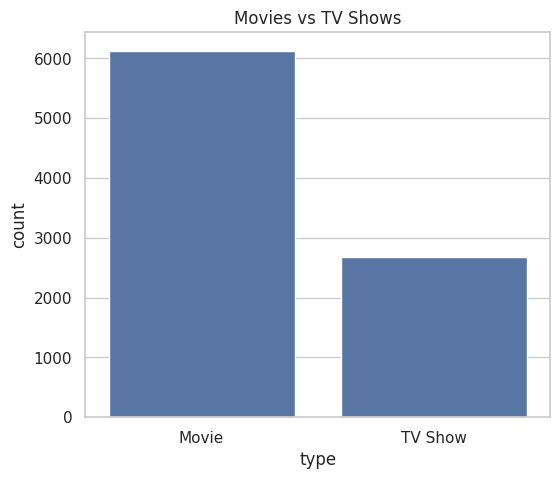

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(x='type', data=df)

plt.title('Movies vs TV Shows')
plt.show()


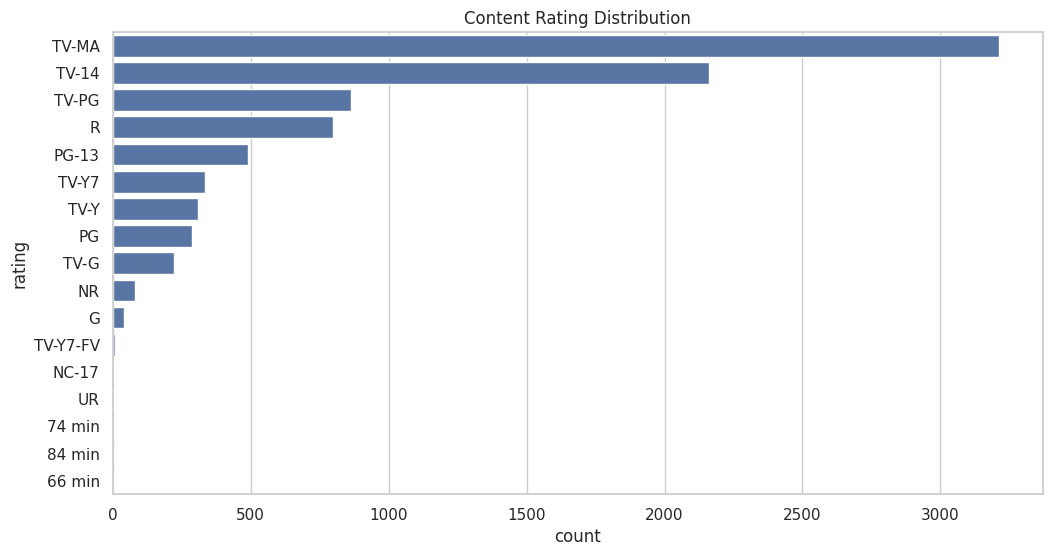

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(y='rating', data=df,
order=df['rating'].value_counts().index)

plt.title('Content Rating Distribution')
plt.show()


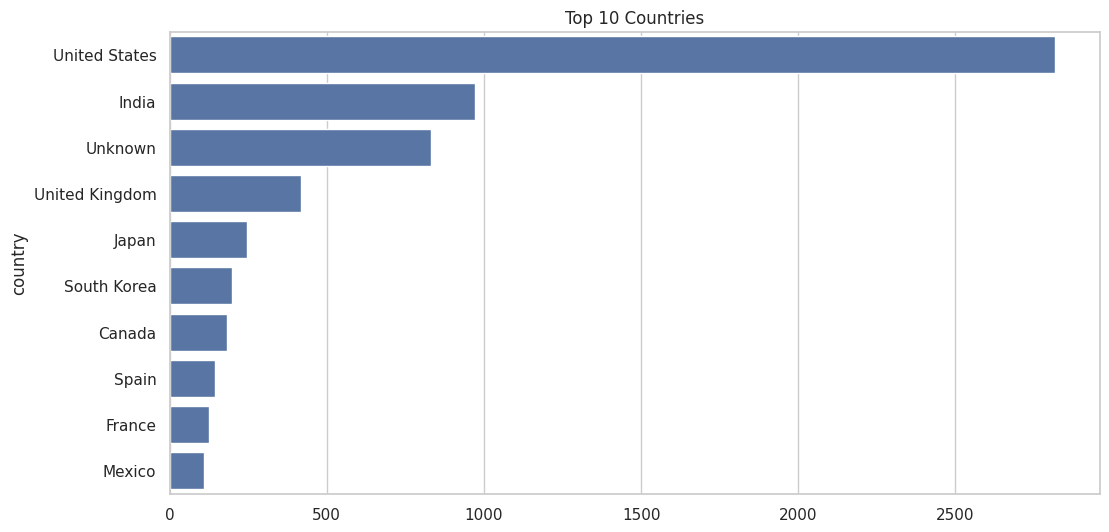

In [ ]:
plt.figure(figsize=(12,6))

country_counts = df['country'].value_counts().head(10)

sns.barplot(x=country_counts.values,
y=country_counts.index)

plt.title('Top 10 Countries')
plt.show()


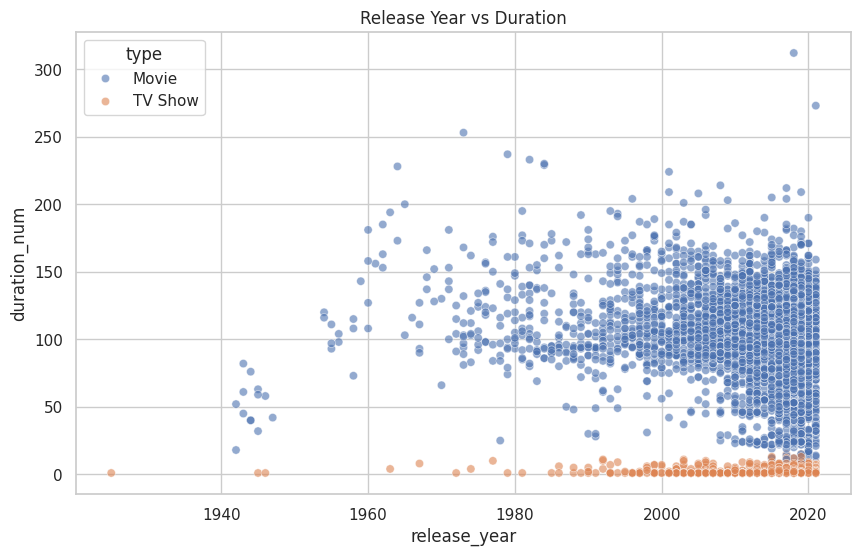

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
x='release_year',
y='duration_num',
hue='type',
data=df,
alpha=0.6
)

plt.title('Release Year vs Duration')
plt.show()


In [ ]:
sample_df = df.sample(500)

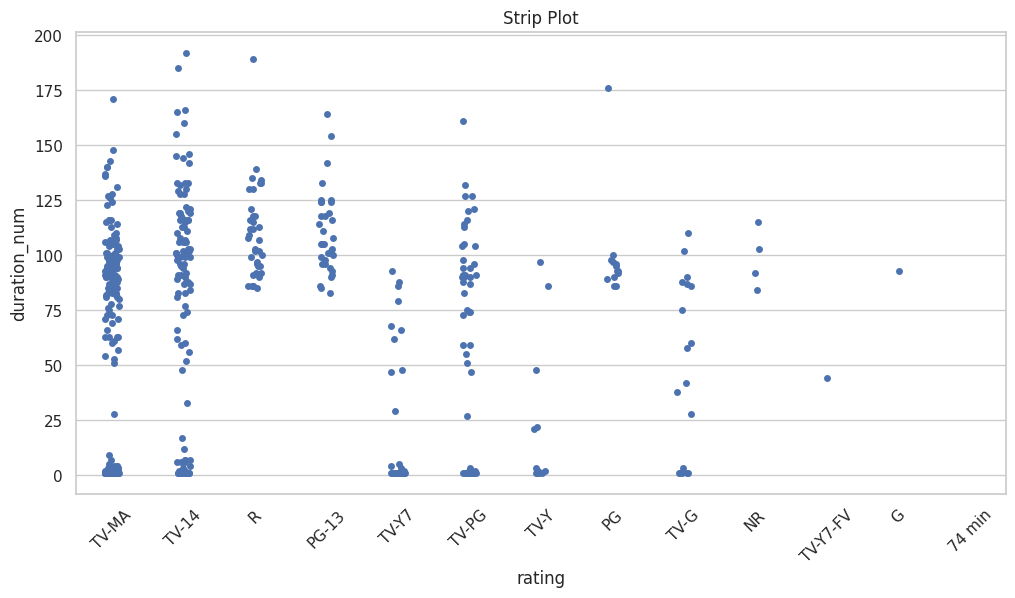

In [ ]:
plt.figure(figsize=(12,6))

sns.stripplot(
x='rating',
y='duration_num',
data= sample_df,
jitter=True
)

plt.xticks(rotation=45)
plt.title('Strip Plot')
plt.show()


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 31.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 12.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 12.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 35.4% of the points cannot be plac

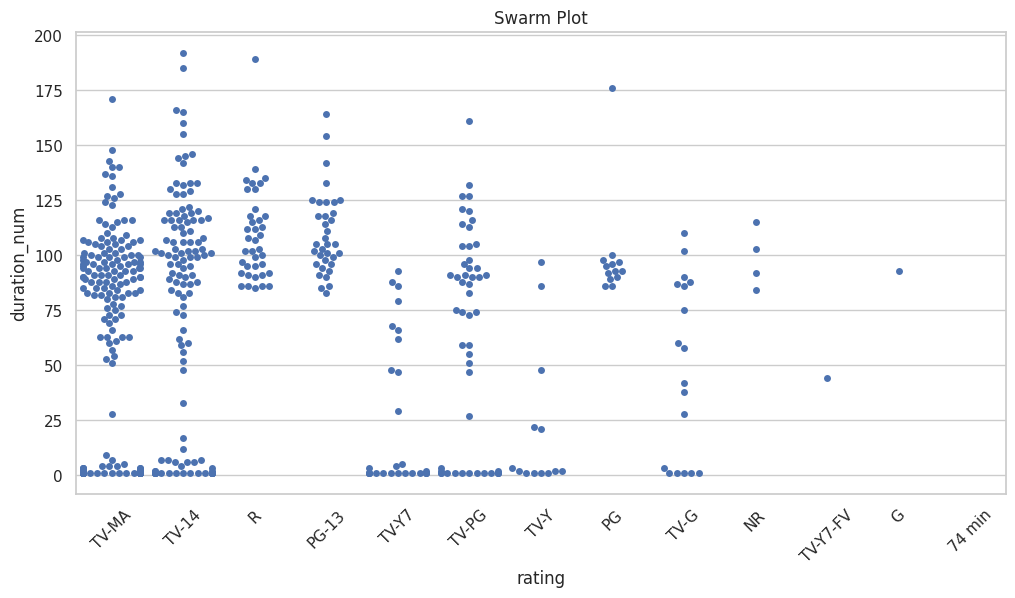

In [ ]:
plt.figure(figsize=(12,6))

sns.swarmplot(
x='rating',
y='duration_num',
data=sample_df
)

plt.xticks(rotation=45)
plt.title('Swarm Plot')
plt.show()


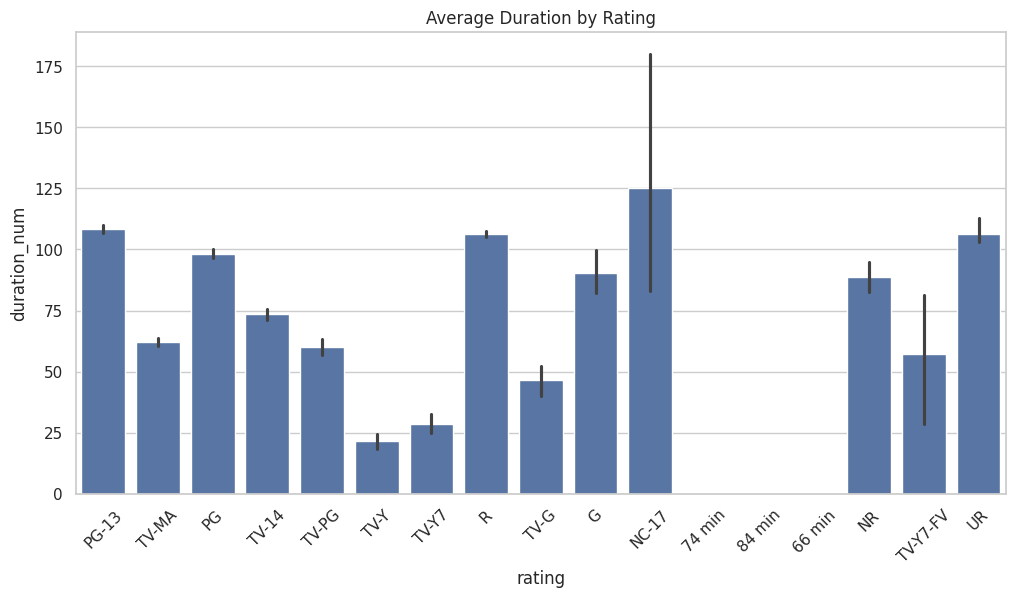

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
x='rating',
y='duration_num',
data=df,
estimator=np.mean
)

plt.xticks(rotation=45)
plt.title('Average Duration by Rating')
plt.show()


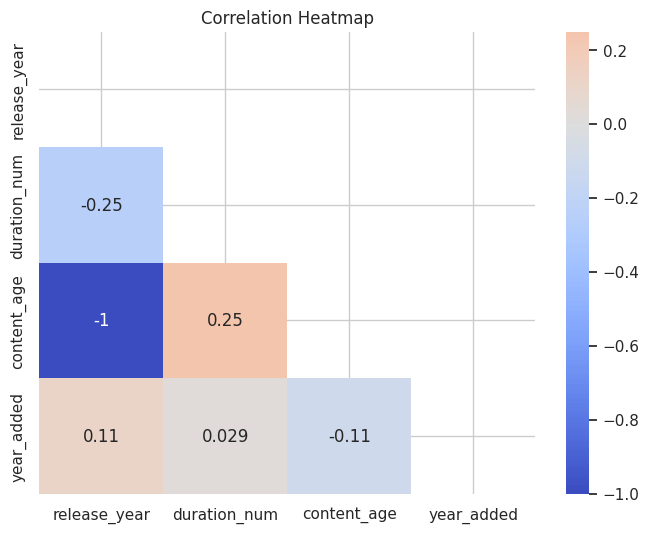

In [ ]:
corr = df[['release_year','duration_num','content_age','year_added']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
corr,
annot=True,
cmap='coolwarm',
mask=mask,
center=0
)

plt.title('Correlation Heatmap')
plt.show()


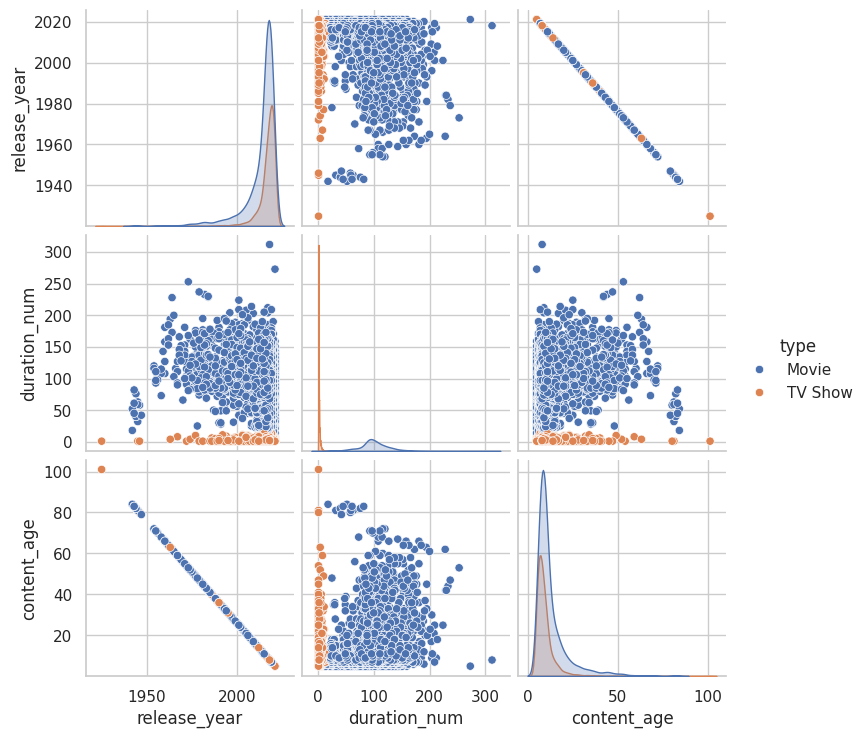

In [ ]:
sns.pairplot(
df[['release_year','duration_num','content_age','type']].dropna(),
hue='type'
)

plt.show()


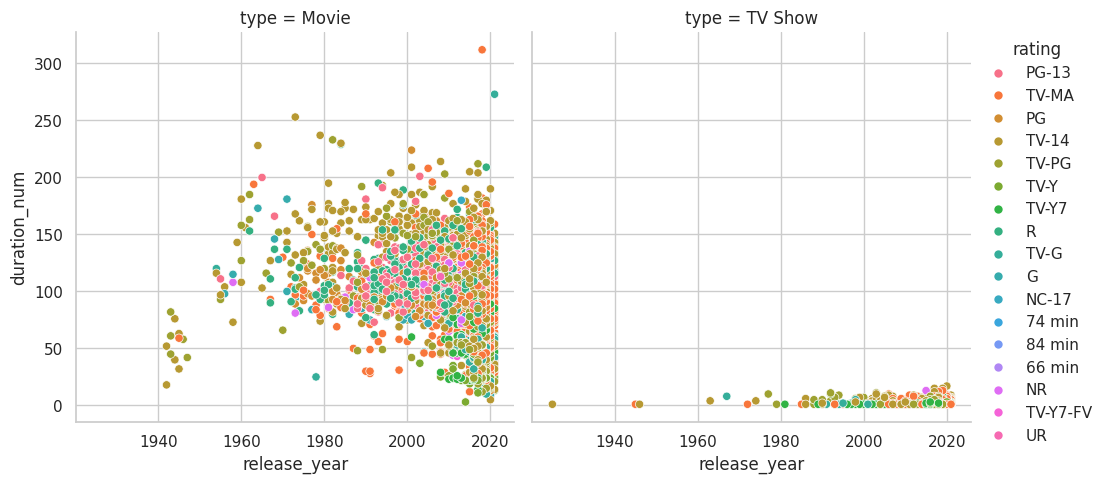

In [ ]:
sns.relplot(
data=df,
x='release_year',
y='duration_num',
col='type',
hue='rating',
kind='scatter'
)

plt.show()


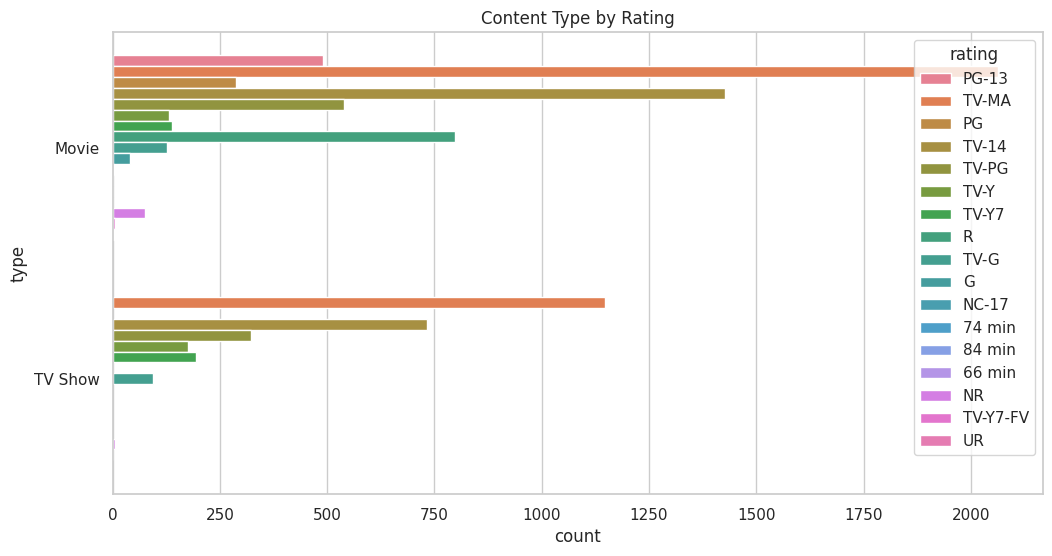

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
y='type',
hue='rating',
data=df
)

plt.title('Content Type by Rating')
plt.show()


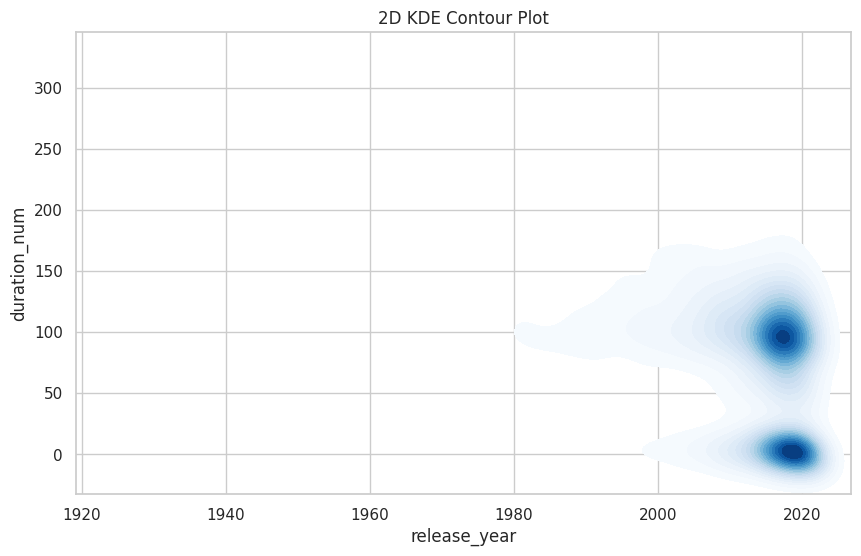

In [ ]:
plt.figure(figsize=(10,6))

sns.kdeplot(
data=df,
x='release_year',
y='duration_num',
fill=True,
levels=20,
cmap='Blues'
)

plt.title('2D KDE Contour Plot')
plt.show()


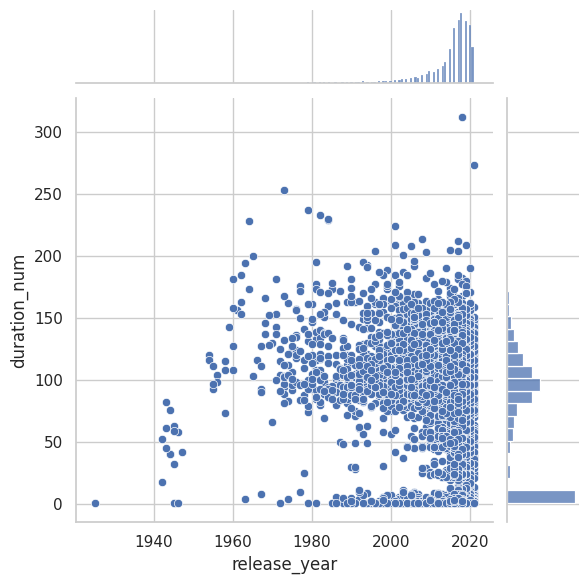

In [ ]:
sns.jointplot(
data=df,
x='release_year',
y='duration_num',
kind='scatter'
)


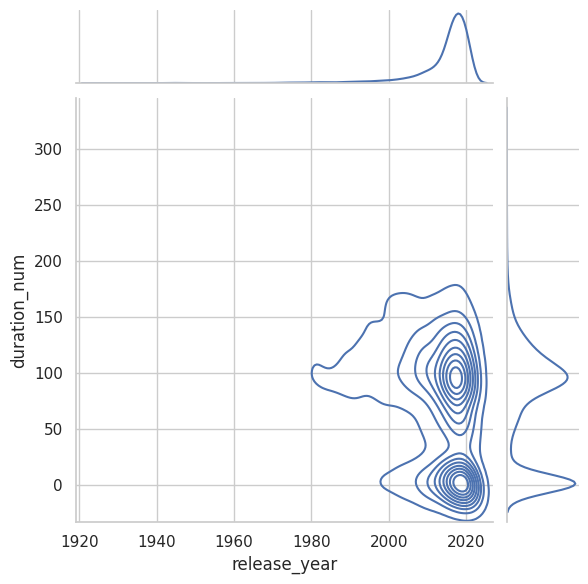

In [ ]:
sns.jointplot(
data=df,
x='release_year',
y='duration_num',
kind='kde'
)


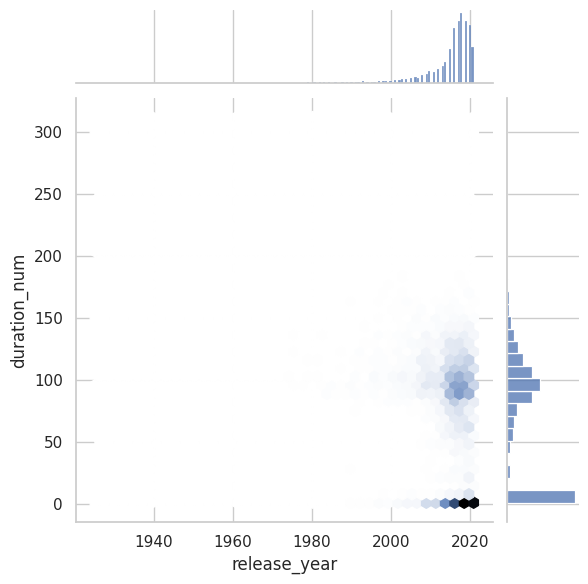

In [ ]:
sns.jointplot(
data=df,
x='release_year',
y='duration_num',
kind='hex'
)


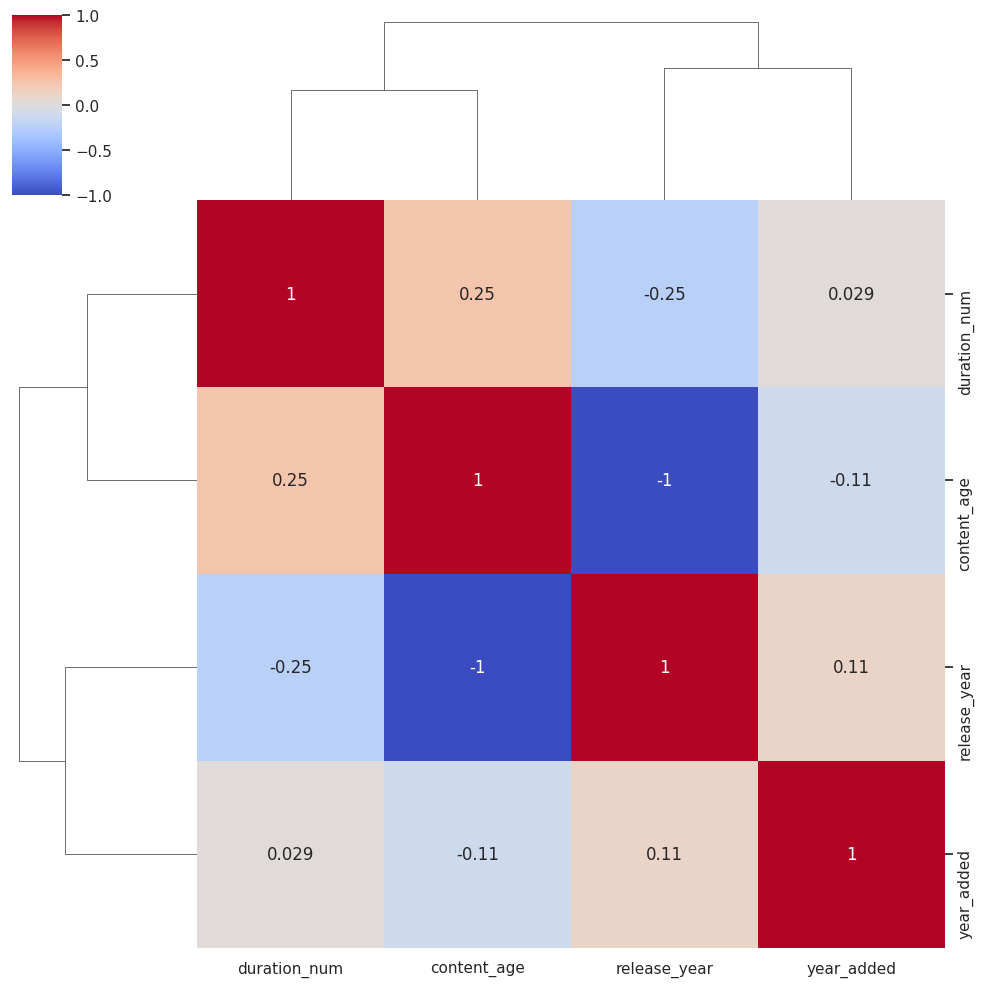

In [ ]:
numeric_df = df[['release_year','duration_num','content_age','year_added']].dropna()

sns.clustermap(
numeric_df.corr(),
annot=True,
cmap='coolwarm'
)

plt.show()


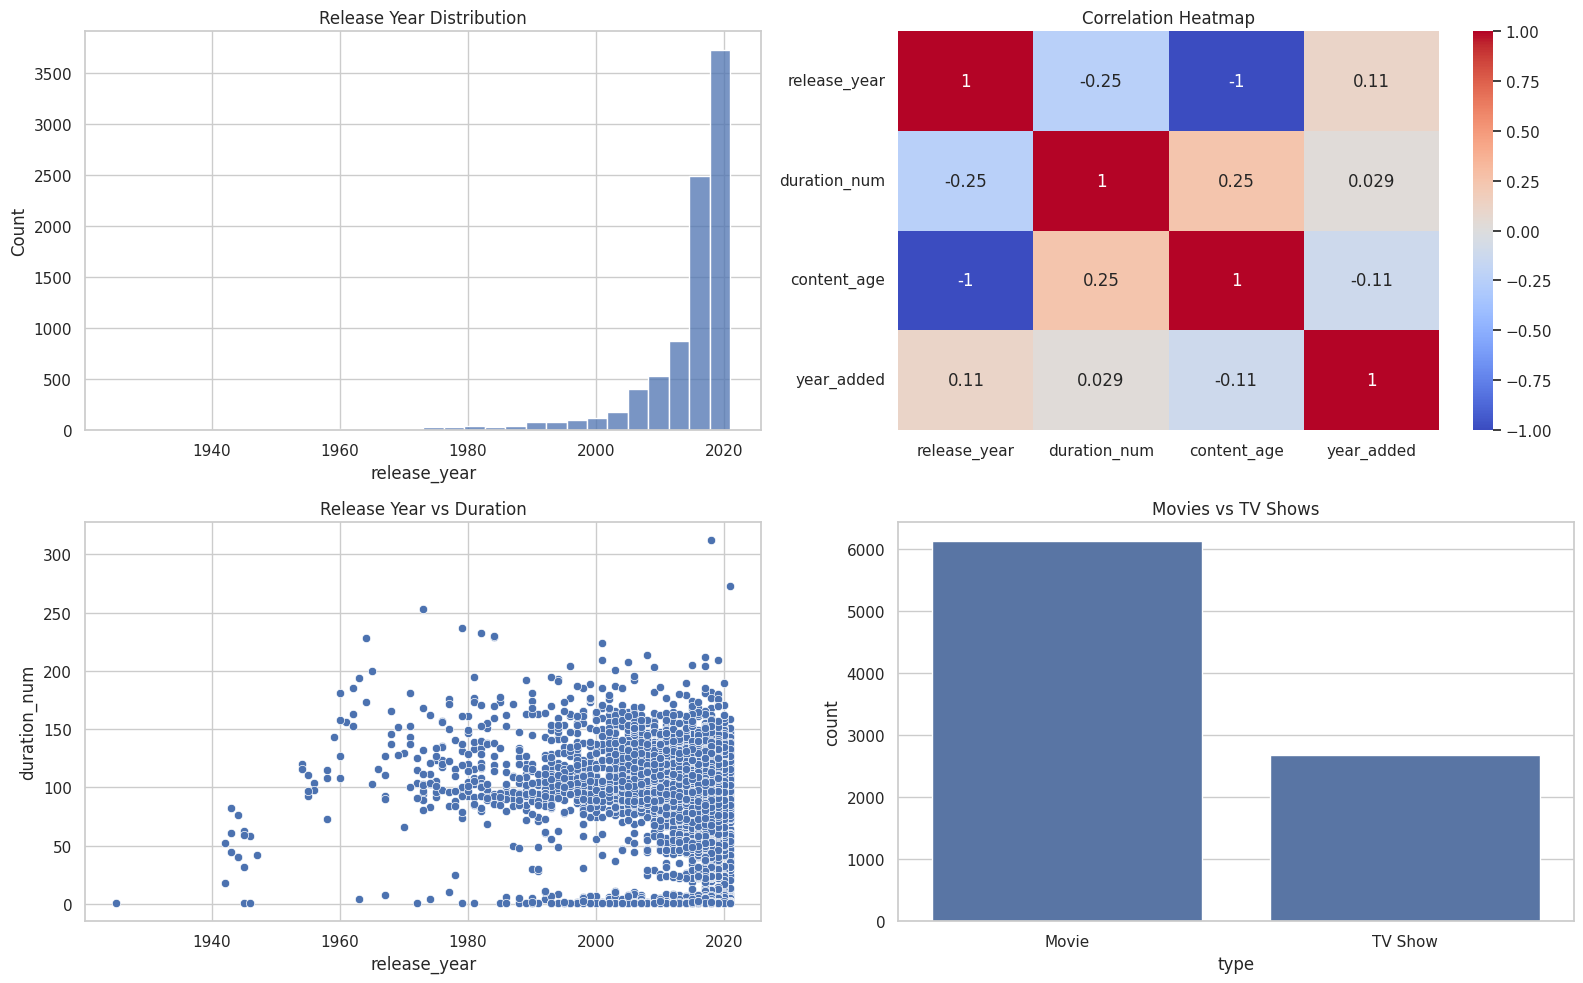

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(16,10))

# Histogram
sns.histplot(df['release_year'], bins=30, ax=axes[0,0])
axes[0,0].set_title('Release Year Distribution')

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[0,1])
axes[0,1].set_title('Correlation Heatmap')

# Scatterplot
sns.scatterplot(
x='release_year',
y='duration_num',
data=df,
ax=axes[1,0]
)
axes[1,0].set_title('Release Year vs Duration')

# Countplot
sns.countplot(x='type', data=df, ax=axes[1,1])
axes[1,1].set_title('Movies vs TV Shows')

plt.tight_layout()
plt.show()
